In [ ]:
# CELL 1: Mount Drive and verify environment
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import numpy as np
import pickle
import matplotlib
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Verify the checkpoint files exist before we do anything else
STGCN_CKPT  = '/content/drive/MyDrive/HRC_Research/checkpoints/stgcn_hri30/best_stgcn_hri30.pt'
CTRGCN_CKPT = '/content/drive/MyDrive/HRC_Research/checkpoints/ctrgcn_hri30/best_ctrgcn_hri30.pt'

# Verify the test data files exist
STGCN_TEST_DATA  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/stgcn_format/test_data.npy'
STGCN_TEST_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/stgcn_format/test_label.pkl'
CTRGCN_TEST_NPZ  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/ctrgcn_format/HRI30_CS.npz'

print("\n--- Checkpoint verification ---")
for name, path in [("ST-GCN checkpoint", STGCN_CKPT), ("CTR-GCN checkpoint", CTRGCN_CKPT)]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024**2
        print(f"{name}: {size_mb:.1f} MB")
    else:
        print(f"MISSING: {name} at {path}")

print("\n--- Test data verification ---")
for name, path in [("ST-GCN test data", STGCN_TEST_DATA),
                   ("ST-GCN test labels", STGCN_TEST_LABEL),
                   ("CTR-GCN npz", CTRGCN_TEST_NPZ)]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024**2
        print(f"{name}: {size_mb:.1f} MB")
    else:
        print(f"MISSING: {name} at {path}")

Mounted at /content/drive
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

--- Checkpoint verification ---
ST-GCN checkpoint: 11.9 MB
CTR-GCN checkpoint: 5.8 MB

--- Test data verification ---
ST-GCN test data: 25.2 MB
ST-GCN test labels: 0.0 MB
CTR-GCN npz: 126.2 MB


In [ ]:
# CELL 2: Clone repos, apply patches, load both models

import os
import sys
import torch
import torch.nn as nn
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ─────────────────────────────────────────────
# PART A: Clone ST-GCN
# ─────────────────────────────────────────────
STGCN_DIR = '/content/st-gcn'
if not os.path.exists(STGCN_DIR):
    os.system(f'git clone https://github.com/yysijie/st-gcn.git {STGCN_DIR}')
    print("ST-GCN cloned.")
else:
    print("ST-GCN already exists.")

# Patch torch.load in ST-GCN's torchlight
stgcn_io = Path(f'{STGCN_DIR}/torchlight/torchlight/io.py')
text = stgcn_io.read_text()
if "weights_only=False" not in text:
    text = text.replace(
        'torch.load(weights_path)',
        'torch.load(weights_path, weights_only=False, map_location="cpu")'
    )
    stgcn_io.write_text(text)
    print("ST-GCN torch.load patch applied.")

# Install ST-GCN torchlight
os.system(f'pip install -e {STGCN_DIR}/torchlight -q')

# ─────────────────────────────────────────────
# PART B: Clone CTR-GCN
# ─────────────────────────────────────────────
CTRGCN_DIR = '/content/CTR-GCN'
if not os.path.exists(CTRGCN_DIR):
    os.system(f'git clone https://github.com/Uason-Chen/CTR-GCN.git {CTRGCN_DIR}')
    print("CTR-GCN cloned.")
else:
    print("CTR-GCN already exists.")

# Install CTR-GCN dependencies
os.system('pip install -q tensorboardX torchpack fvcore iopath yacs thop')
os.system(f'pip install -e {CTRGCN_DIR}/torchlight -q')

# Patch CTR-GCN: torchpack compatibility
ctrgcn_util = Path(f'{CTRGCN_DIR}/torchlight/torchlight/util.py')
text = ctrgcn_util.read_text()
if "try:" not in text or "PaviLogger" not in text.split("try:")[0]:
    text = text.replace(
        "from torchpack.runner.hooks import PaviLogger",
        "try:\n    from torchpack.runner.hooks import PaviLogger\nexcept ImportError:\n    PaviLogger = None"
    )
    ctrgcn_util.write_text(text)
    print("CTR-GCN torchpack patch applied.")

print("\nAll patches done. Now loading model architectures...")

# ─────────────────────────────────────────────
# PART C: Load ST-GCN model with 30 classes
# ─────────────────────────────────────────────
sys.path.insert(0, STGCN_DIR)
from net.st_gcn import Model as STGCN_Model

stgcn_model = STGCN_Model(
    in_channels=3,
    num_class=30,
    dropout=0.5,
    edge_importance_weighting=True,
    graph_args={'layout': 'ntu-rgb+d', 'strategy': 'spatial'}
)

# Load fine-tuned weights
STGCN_CKPT = '/content/drive/MyDrive/HRC_Research/checkpoints/stgcn_hri30/best_stgcn_hri30.pt'
stgcn_ckpt = torch.load(STGCN_CKPT, map_location='cpu', weights_only=False)

# The checkpoint might be a raw state dict or wrapped in a dict with 'model_state_dict'
if isinstance(stgcn_ckpt, dict) and 'model_state_dict' in stgcn_ckpt:
    stgcn_state = stgcn_ckpt['model_state_dict']
else:
    stgcn_state = stgcn_ckpt

# Strip 'module.' prefix if present (from DataParallel training)
stgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in stgcn_state.items()}

stgcn_model.load_state_dict(stgcn_state, strict=True)
stgcn_model = stgcn_model.to(device)
stgcn_model.eval()
print("ST-GCN loaded successfully (30 classes)")

# ─────────────────────────────────────────────
# PART D: Load CTR-GCN model with 30 classes
# ─────────────────────────────────────────────
sys.path.insert(0, CTRGCN_DIR)
from model.ctrgcn import Model as CTRGCN_Model

ctrgcn_model = CTRGCN_Model(
    num_class=30,
    num_point=25,
    num_person=1,
    graph='graph.ntu_rgb_d.Graph',
    graph_args={'labeling_mode': 'spatial'}
)

CTRGCN_CKPT = '/content/drive/MyDrive/HRC_Research/checkpoints/ctrgcn_hri30/best_ctrgcn_hri30.pt'
ctrgcn_ckpt = torch.load(CTRGCN_CKPT, map_location='cpu', weights_only=False)

if isinstance(ctrgcn_ckpt, dict) and 'model_state_dict' in ctrgcn_ckpt:
    ctrgcn_state = ctrgcn_ckpt['model_state_dict']
else:
    ctrgcn_state = ctrgcn_ckpt

# Strip 'module.' prefix if present
ctrgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in ctrgcn_state.items()}

ctrgcn_model.load_state_dict(ctrgcn_state, strict=True)
ctrgcn_model = ctrgcn_model.to(device)
ctrgcn_model.eval()
print("CTR-GCN loaded successfully (30 classes)")

Using device: cuda
ST-GCN cloned.
ST-GCN torch.load patch applied.
CTR-GCN cloned.

All patches done. Now loading model architectures...
ST-GCN loaded successfully (30 classes)
CTR-GCN loaded successfully (30 classes)


In [ ]:
# CELL 3: Load test data for both models
import numpy as np
import pickle
import torch

# ---------------------------------------------
# ST-GCN test data
# ---------------------------------------------
STGCN_TEST_DATA = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/stgcn_format/test_data.npy'
STGCN_TEST_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/stgcn_format/test_label.pkl'

stgcn_test_data = np.load(STGCN_TEST_DATA)

# FIXED: Correct tuple unpacking
with open(STGCN_TEST_LABEL, 'rb') as f:
    _, y_test = pickle.load(f)

stgcn_test_labels = np.array(y_test)

print(f"ST-GCN test data shape: {stgcn_test_data.shape}")
print(f"ST-GCN test labels shape: {stgcn_test_labels.shape}")
print(f"ST-GCN label range: {stgcn_test_labels.min()} to {stgcn_test_labels.max()}")

# ---------------------------------------------
# CTR-GCN test data
# ---------------------------------------------
CTRGCN_NPZ = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/ctrgcn_format/HRI30_CS.npz'

npz = np.load(CTRGCN_NPZ)
print(f"\nCTR-GCN npz keys: {list(npz.keys())}")

ctrgcn_test_data = npz['x_test']
ctrgcn_test_labels = npz['y_test']

print(f"CTR-GCN test data shape: {ctrgcn_test_data.shape}")
print(f"CTR-GCN test labels shape: {ctrgcn_test_labels.shape}")
print(f"CTR-GCN label range: {ctrgcn_test_labels.min()} to {ctrgcn_test_labels.max()}")

# ---------------------------------------------
# Verification
# ---------------------------------------------
# FIXED: Using parentheses instead of backslashes for multi-line asserts
assert stgcn_test_data.shape[0] == ctrgcn_test_data.shape[0], (
    f"Sample count mismatch: ST-GCN={stgcn_test_data.shape[0]}, CTR-GCN={ctrgcn_test_data.shape[0]}"
)

assert (stgcn_test_labels == ctrgcn_test_labels).all(), (
    "Label mismatch between ST-GCN and CTR-GCN test sets!"
)

print(f"\n[PASS] Both test sets loaded: {stgcn_test_data.shape[0]} samples, 30 classes")
print("[PASS] Labels are identical between both formats")

ST-GCN test data shape: (588, 3, 150, 25, 1)
ST-GCN test labels shape: (588,)
ST-GCN label range: 0 to 29

CTR-GCN npz keys: ['x_train', 'y_train', 'x_test', 'y_test']
CTR-GCN test data shape: (588, 3, 150, 25, 1)
CTR-GCN test labels shape: (588,)
CTR-GCN label range: 0 to 29

[PASS] Both test sets loaded: 588 samples, 30 classes
[PASS] Labels are identical between both formats


In [ ]:
# CELL 4: Occlusion simulation benchmark

import torch
import numpy as np
import csv
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ─────────────────────────────────────────────
# Occlusion function
# data shape: (N, C, T, V, M)
# V = 25 joints (indices 0–24)
# We zero out occlusion_rate% of those joints
# ─────────────────────────────────────────────
def apply_occlusion(data_np, occlusion_rate, seed=None):
    """
    Randomly zeros out occlusion_rate% of joints across the entire batch.
    data_np: numpy array of shape (N, C, T, V, M)
    occlusion_rate: float between 0 and 1
    Returns: corrupted numpy array of same shape
    """
    if occlusion_rate == 0.0:
        return data_np.copy()

    if seed is not None:
        np.random.seed(seed)

    data_out = data_np.copy()
    num_joints = data_out.shape[3]  # V = 25
    num_to_zero = max(1, int(round(num_joints * occlusion_rate)))

    # Pick which joints to zero — same joints zeroed for all samples in the batch
    # This simulates a consistent occlusion source (e.g. a fixed robot arm blocking the view)
    joints_to_zero = np.random.choice(num_joints, num_to_zero, replace=False)

    # Zero out all coordinates (C) and all frames (T) for those joints
    data_out[:, :, :, joints_to_zero, :] = 0.0

    return data_out


# ─────────────────────────────────────────────
# Inference function — runs one model on one batch
# Returns: Top-1 accuracy as a float (0–100)
# ─────────────────────────────────────────────
def run_inference(model, data_np, labels_np, batch_size=64):
    """
    Runs model inference over the full dataset in batches.
    data_np: (N, C, T, V, M) numpy array
    labels_np: (N,) numpy array of integer labels
    Returns Top-1 accuracy as percentage float
    """
    model.eval()
    all_preds = []
    N = data_np.shape[0]

    with torch.no_grad():
        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            batch = torch.tensor(data_np[start:end], dtype=torch.float32).to(device)
            # batch shape: (B, C, T, V, M)
            output = model(batch)           # output shape: (B, num_class)
            preds = output.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)

    all_preds = np.concatenate(all_preds)
    correct = (all_preds == labels_np).sum()
    accuracy = 100.0 * correct / N
    return accuracy


# ─────────────────────────────────────────────
# Main experiment loop
# ─────────────────────────────────────────────
OCCLUSION_RATES = [0.0, 0.10, 0.20, 0.30, 0.50]
NUM_TRIALS = 5  # number of independent random trials per rate (except 0%)

# We collect results as a list of dicts for easy CSV export
results = []

print("=" * 65)
print("PHASE 3 — OCCLUSION SIMULATION BENCHMARK")
print("=" * 65)
print(f"Test samples: {stgcn_test_data.shape[0]}")
print(f"Occlusion rates: {[f'{r*100:.0f}%' for r in OCCLUSION_RATES]}")
print(f"Trials per rate: {NUM_TRIALS} (1 trial at 0%)")
print("=" * 65)

for rate in OCCLUSION_RATES:
    rate_label = f"{int(rate * 100)}%"
    n_trials = 1 if rate == 0.0 else NUM_TRIALS
    print(f"\n--- Occlusion rate: {rate_label} ({n_trials} trial(s)) ---")

    stgcn_accs  = []
    ctrgcn_accs = []

    for trial in range(n_trials):
        seed = 42 + trial  # reproducible but varied across trials

        # Apply occlusion to both datasets (same joints zeroed — same seed)
        st_corrupted  = apply_occlusion(stgcn_test_data,  rate, seed=seed)
        ctr_corrupted = apply_occlusion(ctrgcn_test_data, rate, seed=seed)

        # Run ST-GCN
        st_acc = run_inference(stgcn_model, st_corrupted, stgcn_test_labels)
        stgcn_accs.append(st_acc)

        # Run CTR-GCN
        ctr_acc = run_inference(ctrgcn_model, ctr_corrupted, ctrgcn_test_labels)
        ctrgcn_accs.append(ctr_acc)

        print(f"  Trial {trial+1}: ST-GCN = {st_acc:.2f}%  |  CTR-GCN = {ctr_acc:.2f}%")

    # Average over trials
    st_mean  = float(np.mean(stgcn_accs))
    ctr_mean = float(np.mean(ctrgcn_accs))
    st_std   = float(np.std(stgcn_accs))
    ctr_std  = float(np.std(ctrgcn_accs))

    print(f"  → Mean: ST-GCN = {st_mean:.2f}% (±{st_std:.2f})  |  CTR-GCN = {ctr_mean:.2f}% (±{ctr_std:.2f})")

    results.append({
        'occlusion_rate': rate_label,
        'stgcn_trial_accs': stgcn_accs,
        'ctrgcn_trial_accs': ctrgcn_accs,
        'stgcn_mean': st_mean,
        'ctrgcn_mean': ctr_mean,
        'stgcn_std': st_std,
        'ctrgcn_std': ctr_std
    })

print("\n" + "=" * 65)
print("BENCHMARK COMPLETE")
print("=" * 65)

# ─────────────────────────────────────────────
# Save results CSV to Drive
# ─────────────────────────────────────────────
OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark'
os.makedirs(OUTPUT_DIR, exist_ok=True)
CSV_PATH = os.path.join(OUTPUT_DIR, 'occlusion_results.csv')

with open(CSV_PATH, 'w', newline='') as f:
    writer = csv.writer(f)
    # Header
    writer.writerow([
        'occlusion_rate',
        'stgcn_trial_1', 'stgcn_trial_2', 'stgcn_trial_3', 'stgcn_trial_4', 'stgcn_trial_5',
        'stgcn_mean', 'stgcn_std',
        'ctrgcn_trial_1', 'ctrgcn_trial_2', 'ctrgcn_trial_3', 'ctrgcn_trial_4', 'ctrgcn_trial_5',
        'ctrgcn_mean', 'ctrgcn_std'
    ])
    for r in results:
        # Pad trial lists to 5 entries with empty string for the 0% row (only 1 trial)
        st_trials  = r['stgcn_trial_accs']  + [''] * (5 - len(r['stgcn_trial_accs']))
        ctr_trials = r['ctrgcn_trial_accs'] + [''] * (5 - len(r['ctrgcn_trial_accs']))
        writer.writerow([
            r['occlusion_rate'],
            *[f"{v:.4f}" if v != '' else '' for v in st_trials],
            f"{r['stgcn_mean']:.4f}", f"{r['stgcn_std']:.4f}",
            *[f"{v:.4f}" if v != '' else '' for v in ctr_trials],
            f"{r['ctrgcn_mean']:.4f}", f"{r['ctrgcn_std']:.4f}"
        ])

csv_size_kb = os.path.getsize(CSV_PATH) / 1024
print(f"\nCSV saved to Drive: {CSV_PATH}")
print(f"   File size: {csv_size_kb:.2f} KB")

PHASE 3 — OCCLUSION SIMULATION BENCHMARK
Test samples: 588
Occlusion rates: ['0%', '10%', '20%', '30%', '50%']
Trials per rate: 5 (1 trial at 0%)

--- Occlusion rate: 0% (1 trial(s)) ---
  Trial 1: ST-GCN = 61.22%  |  CTR-GCN = 69.05%
  → Mean: ST-GCN = 61.22% (±0.00)  |  CTR-GCN = 69.05% (±0.00)

--- Occlusion rate: 10% (5 trial(s)) ---
  Trial 1: ST-GCN = 56.97%  |  CTR-GCN = 57.31%
  Trial 2: ST-GCN = 56.97%  |  CTR-GCN = 52.55%
  Trial 3: ST-GCN = 49.15%  |  CTR-GCN = 59.01%
  Trial 4: ST-GCN = 43.03%  |  CTR-GCN = 52.72%
  Trial 5: ST-GCN = 39.12%  |  CTR-GCN = 42.18%
  → Mean: ST-GCN = 49.05% (±7.22)  |  CTR-GCN = 52.76% (±5.86)

--- Occlusion rate: 20% (5 trial(s)) ---
  Trial 1: ST-GCN = 39.63%  |  CTR-GCN = 32.82%
  Trial 2: ST-GCN = 50.85%  |  CTR-GCN = 36.90%
  Trial 3: ST-GCN = 36.56%  |  CTR-GCN = 45.92%
  Trial 4: ST-GCN = 40.82%  |  CTR-GCN = 34.18%
  Trial 5: ST-GCN = 34.52%  |  CTR-GCN = 35.37%
  → Mean: ST-GCN = 40.48% (±5.64)  |  CTR-GCN = 37.04% (±4.64)

--- Occlusi

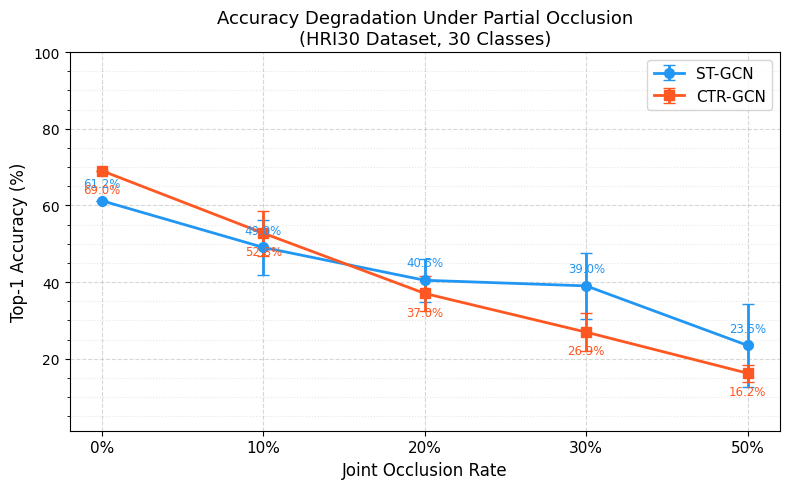


Plot saved to Drive: /content/drive/MyDrive/HRC_Research/results/occlusion_benchmark/accuracy_degradation_curves.png
   File size: 93.0 KB

FINAL SUMMARY TABLE
Occlusion       ST-GCN Mean   CTR-GCN Mean      Gap
-------------------------------------------------------
0%                   61.22%          69.05%    +7.82pp
10%                  49.05%          52.76%    +3.71pp
20%                  40.48%          37.04%    -3.44pp
30%                  39.01%          26.94%   -12.07pp
50%                  23.47%          16.22%    -7.24pp


In [ ]:
# CELL 5: Plot accuracy degradation curves and save to Drive

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# ─────────────────────────────────────────────
# Extract numbers from results list
# (results was built in Cell 4 — must run that cell first)
# ─────────────────────────────────────────────
occlusion_labels = [r['occlusion_rate'] for r in results]  # ['0%', '10%', '20%', '30%', '50%']
stgcn_means  = [r['stgcn_mean']  for r in results]
ctrgcn_means = [r['ctrgcn_mean'] for r in results]
stgcn_stds   = [r['stgcn_std']   for r in results]
ctrgcn_stds  = [r['ctrgcn_std']  for r in results]

x = list(range(len(occlusion_labels)))  # [0, 1, 2, 3, 4]

# ─────────────────────────────────────────────
# Build the figure
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# ST-GCN line
ax.errorbar(x, stgcn_means, yerr=stgcn_stds,
            label='ST-GCN', marker='o', color='#2196F3',
            linewidth=2, markersize=7, capsize=4)

# CTR-GCN line
ax.errorbar(x, ctrgcn_means, yerr=ctrgcn_stds,
            label='CTR-GCN', marker='s', color='#FF5722',
            linewidth=2, markersize=7, capsize=4)

# Annotate each point with its mean accuracy
for i, (st, ctr) in enumerate(zip(stgcn_means, ctrgcn_means)):
    ax.annotate(f'{st:.1f}%', xy=(i, st),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8.5, color='#2196F3')
    ax.annotate(f'{ctr:.1f}%', xy=(i, ctr),
                xytext=(0, -16), textcoords='offset points',
                ha='center', fontsize=8.5, color='#FF5722')

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(occlusion_labels, fontsize=11)
ax.set_xlabel('Joint Occlusion Rate', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
ax.set_title('Accuracy Degradation Under Partial Occlusion\n(HRI30 Dataset, 30 Classes)', fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

# Set y-axis range with some padding
min_val = min(min(stgcn_means), min(ctrgcn_means))
ax.set_ylim(max(0, min_val - 15), 100)

plt.tight_layout()

# ─────────────────────────────────────────────
# Save to Drive
# ─────────────────────────────────────────────
OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark'
os.makedirs(OUTPUT_DIR, exist_ok=True)
PLOT_PATH = os.path.join(OUTPUT_DIR, 'accuracy_degradation_curves.png')

plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

plot_size_kb = os.path.getsize(PLOT_PATH) / 1024
print(f"\nPlot saved to Drive: {PLOT_PATH}")
print(f"   File size: {plot_size_kb:.1f} KB")

# ─────────────────────────────────────────────
# Print a clean summary table to console
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("FINAL SUMMARY TABLE")
print("=" * 55)
print(f"{'Occlusion':<12} {'ST-GCN Mean':>14} {'CTR-GCN Mean':>14} {'Gap':>8}")
print("-" * 55)
for r in results:
    gap = r['ctrgcn_mean'] - r['stgcn_mean']
    print(f"{r['occlusion_rate']:<12} {r['stgcn_mean']:>13.2f}%  {r['ctrgcn_mean']:>13.2f}%  {gap:>+7.2f}pp")
print("=" * 55)